In [ ]:
!pip install -q transformers

In [ ]:
from transformers import RobertaTokenizerFast, TFRobertaForSequenceClassification, pipeline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
sentiment_pipeline = pipeline("sentiment-analysis")
data = ["I love you", "I hate you"]
sentiment_pipeline(data)

In [ ]:
# download pre-trained emotion classification model
emotion = pipeline("text-classification", model="j-hartmann/emotion-english-distilroberta-base")

emotion(data)

In [ ]:
df = pd.read_csv('SkyIsland.csv')

In [ ]:
df.head(5)

,web-scraper-order,web-scraper-start-url,link,link-href,comment
0,1735057809-16,https://transcripts.foreverdreaming.org/viewfo...,05x136 - Zenny of the Island of Goats and the ...,https://transcripts.foreverdreaming.org/viewto...,Zenny lives on the island of the goat There is...
1,1735057812-17,https://transcripts.foreverdreaming.org/viewfo...,05x137 - How's Tricks? The Designs of Zenny th...,https://transcripts.foreverdreaming.org/viewto...,"How do you hope to pay? Ambition of Zenny, prê..."
2,1735057816-18,https://transcripts.foreverdreaming.org/viewfo...,05x138 - Whereabouts of the Island Treasure! A...,https://transcripts.foreverdreaming.org/viewto...,It is A trap! The Navy their tightened a trap...
3,1735057821-19,https://transcripts.foreverdreaming.org/viewfo...,05x139 - Legend of the Rainbow Mist! Old Man H...,https://transcripts.foreverdreaming.org/viewto...,Fact of sh1tting! Fact of sh1tting! Fact of sh...
4,1735057823-20,https://transcripts.foreverdreaming.org/viewfo...,05x140 - Residents of the Land of Eternity! Th...,https://transcripts.foreverdreaming.org/viewto...,Then it is you the poor cretins which refused ...


In [ ]:
df.drop(['web-scraper-order', 'web-scraper-start-url'], axis=1, inplace=True)

In [ ]:
df.head(5)

,link,link-href,comment
0,05x136 - Zenny of the Island of Goats and the ...,https://transcripts.foreverdreaming.org/viewto...,Zenny lives on the island of the goat There is...
1,05x137 - How's Tricks? The Designs of Zenny th...,https://transcripts.foreverdreaming.org/viewto...,"How do you hope to pay? Ambition of Zenny, prê..."
2,05x138 - Whereabouts of the Island Treasure! A...,https://transcripts.foreverdreaming.org/viewto...,It is A trap! The Navy their tightened a trap...
3,05x139 - Legend of the Rainbow Mist! Old Man H...,https://transcripts.foreverdreaming.org/viewto...,Fact of sh1tting! Fact of sh1tting! Fact of sh...
4,05x140 - Residents of the Land of Eternity! Th...,https://transcripts.foreverdreaming.org/viewto...,Then it is you the poor cretins which refused ...


In [ ]:
MAX_LENGTH = 512  # ขีดจำกัดของโมเดล
df['comment'] = df['comment'].apply(lambda x: x[:MAX_LENGTH] if isinstance(x, str) else "")
#ตัดข้อความให้สั้นลงก่อนประมวลผล

In [ ]:
df['comment'] = df['comment'].str.replace('\n', '').str.replace('\r', '').str.replace('', '')

In [ ]:
df['sentiment'] = df.comment.apply(lambda x: sentiment_pipeline(x)[0]['label'])

In [ ]:
df['emotion'] = df.comment.apply(lambda x: emotion(x)[0]['label'])

In [ ]:
df.head(5)

,link,link-href,comment,sentiment,emotion
0,05x136 - Zenny of the Island of Goats and the ...,https://transcripts.foreverdreaming.org/viewto...,Zenny lives on the island of the goat There is...,NEGATIVE,anger
1,05x137 - How's Tricks? The Designs of Zenny th...,https://transcripts.foreverdreaming.org/viewto...,"How do you hope to pay? Ambition of Zenny, prê...",POSITIVE,anger
2,05x138 - Whereabouts of the Island Treasure! A...,https://transcripts.foreverdreaming.org/viewto...,It is A trap! The Navy their tightened a trap...,NEGATIVE,surprise
3,05x139 - Legend of the Rainbow Mist! Old Man H...,https://transcripts.foreverdreaming.org/viewto...,Fact of sh1tting! Fact of sh1tting! Fact of sh...,NEGATIVE,anger
4,05x140 - Residents of the Land of Eternity! Th...,https://transcripts.foreverdreaming.org/viewto...,Then it is you the poor cretins which refused ...,NEGATIVE,disgust


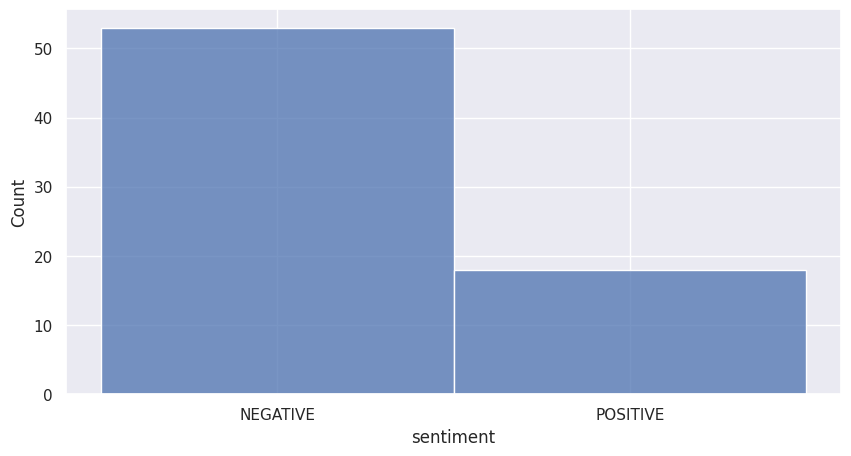

In [ ]:
sns.set(rc={'figure.figsize':(10,5)})
fig = sns.histplot(df['sentiment'])

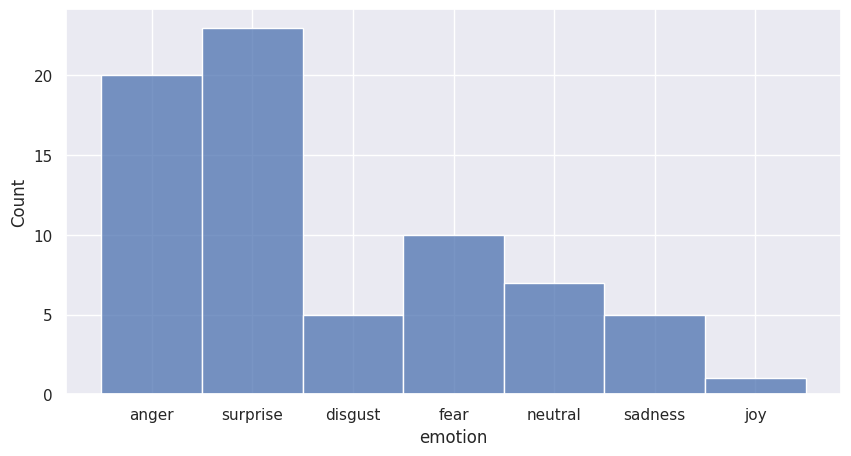

In [ ]:
sns.set(rc={'figure.figsize':(10,5)})
fig = sns.histplot(df['emotion'])

In [ ]:
df.to_csv('SoothingRelaxation-done.csv', index=False)

In [ ]:
from wordcloud import WordCloud
from wordcloud import STOPWORDS

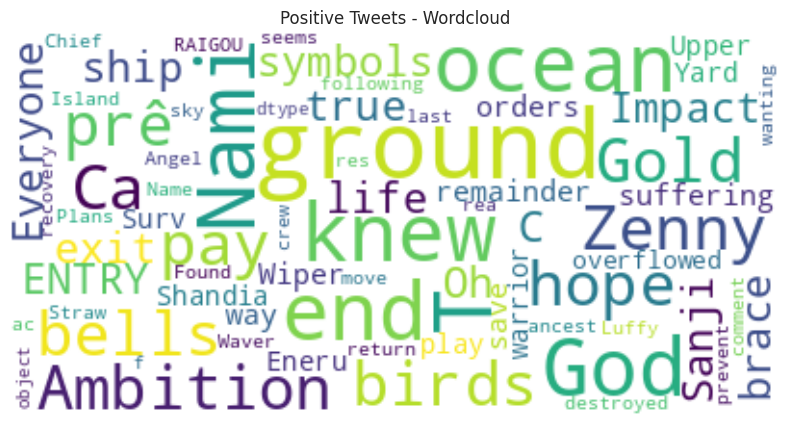

In [ ]:
# Wordcloud with positive
msg = df['comment'][df["sentiment"] == 'POSITIVE']
stop_words = list(STOPWORDS)
positive_wordcloud = WordCloud(max_font_size=50, max_words=100, background_color="white", stopwords = stop_words).generate(str(msg))
plt.figure()
plt.title("Positive Tweets - Wordcloud")
plt.imshow(positive_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()


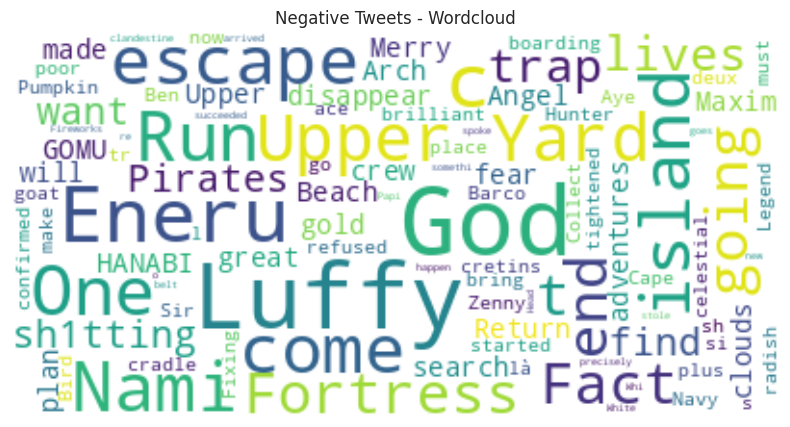

In [ ]:
 # Wordcloud with negative
msg = df['comment'][df["sentiment"] == 'NEGATIVE']
stop_words = ["https", "co", "RT"] + list(STOPWORDS)
negative_wordcloud = WordCloud(max_font_size=50, max_words=100, background_color="white", stopwords = stop_words).generate(str(msg))
plt.figure()
plt.title("Negative Tweets - Wordcloud")
plt.imshow(negative_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()


In [ ]:
msg = df['comment']
stop_words = ["https", "co", "RT"] + list(STOPWORDS)
negative_wordcloud = WordCloud(max_font_size=50, max_words=100, background_color="white", stopwords = stop_words).generate(str(msg))
plt.figure()
plt.title("Negative Tweets - Wordcloud")
plt.imshow(negative_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()


In [ ]:
msg = df['comment'][df['emotion'] == 'JOY']
stop_words = ["https", "co", "RT"] + list(STOPWORDS)
negative_wordcloud = WordCloud(max_font_size=50, max_words=100, background_color="white", stopwords = stop_words).generate(str(msg))
plt.figure()
plt.title("Negative Tweets - Wordcloud")
plt.imshow(negative_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()
